In [1]:
from pathlib import Path
import datajoint as dj

dj.config.load(
    Path("dj_local_conf.json").absolute()
)  # replace with your config file name

/home/sgao/source/miniforge3/envs/spyglass/lib/python3.10/site-packages/datajoint/plugin.py:4: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
[2026-10-03 14:18:08,939][INFO]: DataJoint is configured from /home/sgao/source/sgao_analysis/dj_local_conf.json


In [2]:
from spyglass.spikesorting.analysis.v1.group import SortedSpikesGroup
SortedSpikesGroup()

[2026-10-03 14:18:20,381][INFO]: DataJoint 0.14.5 connected to sgao@lmf-db.cin.ucsf.edu:3306


nwb_file_name name of the NWB file,unit_filter_params_name,sorted_spikes_group_name
Bilbo20230724_.nwb,default_exclusion,04_lineartrack
Bilbo20230724_.nwb,default_exclusion,06_lineartrack
Bilbo20230724_.nwb,default_exclusion,08_lineartrack
Bilbo20230724_.nwb,default_exclusion,10_lineartrack
Bilbo20230724_.nwb,default_exclusion,12_lineartrack
Bilbo20230725_.nwb,default_exclusion,02_lineartrack
Bilbo20230725_.nwb,default_exclusion,04_lineartrack
Bilbo20230725_.nwb,default_exclusion,06_lineartrack
Bilbo20230725_.nwb,default_exclusion,08_lineartrack
Bilbo20230725_.nwb,default_exclusion,10_lineartrack


In [16]:
from spyglass.spikesorting.analysis.v1.group import SortedSpikesGroup

(SortedSpikesGroup & 'nwb_file_name LIKE "marcus%"').fetch("nwb_file_name")

array(['Marcus20260727_.nwb', 'Marcus20260801_.nwb',
       'Marcus20260802_.nwb', 'Marcus20260803_.nwb'], dtype=object)

In [17]:
SortedSpikesGroup & {"nwb_file_name": "Marcus20260727_.nwb"}

nwb_file_name name of the NWB file,unit_filter_params_name,sorted_spikes_group_name
Marcus20260727_.nwb,exclude_all_other,mPFC


In [20]:
from spyglass.spikesorting.analysis.v1.group import SortedSpikesGroup

nwb_file_name = "Marcus20260727_.nwb"

group_key = {
    "nwb_file_name": nwb_file_name,
    "sorted_spikes_group_name":"mPFC",
}
SortedSpikesGroup & group_key

nwb_file_name name of the NWB file,unit_filter_params_name,sorted_spikes_group_name
Marcus20260727_.nwb,exclude_all_other,mPFC


In [ ]:
# here we can see that I put 4 sort groups (4 shanks in the mPFC) into this one sorted spikes group
SortedSpikesGroup.Units & group_key

nwb_file_name name of the NWB file,unit_filter_params_name,sorted_spikes_group_name,spikesorting_merge_id
Marcus20260727_.nwb,exclude_all_other,mPFC,3bb58dbc-a67b-7849-b360-2d6fb7460c3f
Marcus20260727_.nwb,exclude_all_other,mPFC,435b3977-2bc5-f7ff-0987-320164c9ead5
Marcus20260727_.nwb,exclude_all_other,mPFC,8f1ad387-e4ba-96f5-de74-b912d54866a2
Marcus20260727_.nwb,exclude_all_other,mPFC,a0e492ce-341c-874f-10af-f3c4bf5ad07b


In [22]:
from spyglass.spikesorting.analysis.v1.group import SortedSpikesGroup
group_key ={'nwb_file_name': 'Marcus20260727_.nwb',
 'sorted_spikes_group_name': 'mPFC'}

In [23]:
# get the complete key
group_key = (SortedSpikesGroup & group_key).fetch1("KEY")
# get the spike data, returns a list of unit spike times
SortedSpikesGroup().fetch_spike_data(group_key)

[14:30:29][WARNING] Spyglass: Missing code for CurationV2
/home/sgao/source/miniforge3/envs/spyglass/lib/python3.10/site-packages/hdmf/backends/hdf5/h5tools.py:620: BrokenLinkWarning: Path to Group altered/broken at /general/devices/MarketTech LuxX+ Red/model
  warnings.warn('Path to Group altered/broken at ' + os.path.join(h5obj.name, k), BrokenLinkWarning)
/home/sgao/source/miniforge3/envs/spyglass/lib/python3.10/site-packages/hdmf/backends/hdf5/h5tools.py:620: BrokenLinkWarning: Path to Group altered/broken at /general/devices/Optical fiber 1/model
  warnings.warn('Path to Group altered/broken at ' + os.path.join(h5obj.name, k), BrokenLinkWarning)
/home/sgao/source/miniforge3/envs/spyglass/lib/python3.10/site-packages/hdmf/backends/hdf5/h5tools.py:620: BrokenLinkWarning: Path to Group altered/broken at /general/devices/Optical fiber 2/model
  warnings.warn('Path to Group altered/broken at ' + os.path.join(h5obj.name, k), BrokenLinkWarning)
/home/sgao/source/miniforge3/envs/spyglass/

[array([1.78517754e+09, 1.78517754e+09, 1.78517754e+09, ...,
        1.78518180e+09, 1.78518181e+09, 1.78518181e+09]),
 array([1.78517754e+09, 1.78517754e+09, 1.78517754e+09, ...,
        1.78518180e+09, 1.78518180e+09, 1.78518180e+09]),
 array([1.78517754e+09, 1.78517754e+09, 1.78517754e+09, ...,
        1.78518181e+09, 1.78518181e+09, 1.78518181e+09]),
 array([1.78517754e+09, 1.78517754e+09, 1.78517754e+09, ...,
        1.78518181e+09, 1.78518181e+09, 1.78518181e+09]),
 array([1.78517754e+09, 1.78517754e+09, 1.78517754e+09, ...,
        1.78518181e+09, 1.78518181e+09, 1.78518181e+09]),
 array([1.78517754e+09, 1.78517754e+09, 1.78517754e+09, ...,
        1.78518180e+09, 1.78518181e+09, 1.78518181e+09]),
 array([1.78517754e+09, 1.78517754e+09, 1.78517754e+09, ...,
        1.78518181e+09, 1.78518181e+09, 1.78518181e+09]),
 array([1.78517754e+09, 1.78517754e+09, 1.78517754e+09, ...,
        1.78518181e+09, 1.78518181e+09, 1.78518181e+09]),
 array([1.78517754e+09, 1.78517754e+09, 1.785177

In [24]:
import pynwb

pynwb.__version__

'3.1.3'

In [25]:
spike_times, unit_ids = SortedSpikesGroup().fetch_spike_data(
    group_key, return_unit_ids=True
)

[14:31:09][WARNING] Spyglass: Missing code for CurationV2


In [27]:
import numpy as np
import pynwb
import spyglass.common as sgc

#this reads the raw nwb file so we can get laser DIO times
io = pynwb.NWBHDF5IO("/stelmo/nwb/raw/Marcus20260727.nwb", mode="r")
nwbf = io.read()

In [28]:
epoch_number = 0 # this goes from 0-9 and we can reference the google sheet to figure what laser power it is

epoch_start_time, epoch_stop_time, epoch_name = nwbf.intervals['epochs'][epoch_number].to_numpy()[0]

laser_data = nwbf.processing['behavior'].data_interfaces['behavioral_events'].time_series['Laser'].data[:]
laser_timestamps = nwbf.processing['behavior'].data_interfaces['behavioral_events'].time_series['Laser'].timestamps[:]

# Restrict to epoch
mask = (laser_timestamps > epoch_start_time) & (laser_timestamps <= epoch_stop_time)

laser_data_epoch = laser_data[mask]
laser_timestamps_epoch = laser_timestamps[mask]

# Ensure clean start
laser_data_epoch[0] = 0

# --- KEY STEP: only look at ON samples ---
laser_on_times_epoch = laser_timestamps_epoch[laser_data_epoch == 1]

# --- Detect first pulse of each train ---
first_laser_on_times = laser_on_times_epoch[
    np.insert(np.diff(laser_on_times_epoch) > 0.01, 0, True)
]

In [31]:
unit = spike_times[2]
laser = first_laser_on_times[0]

window_spikes = unit[(unit > laser - 0.2) & (unit < laser + 0.2)]
print(window_spikes - laser)

[-0.17106843 -0.15716815 -0.15400147 -0.11170101 -0.08373427 -0.02183366
  0.01613355  0.04003358  0.06026721  0.06650043  0.08806753  0.0957675
  0.11023426  0.1344347   0.15900159  0.18326855  0.19803524]


Laser 0

In [30]:
mi_list = []

for unit in spike_times:

    pre_counts = []
    post_counts = []

    for laser in first_laser_on_times:
        pre = np.sum((unit >= laser - 0.2) & (unit < laser))
        post = np.sum((unit >= laser) & (unit < laser + 0.2))

        pre_counts.append(pre)
        post_counts.append(post)

    pre_avg = np.mean(pre_counts)
    post_avg = np.mean(post_counts)

    mi = (post_avg - pre_avg) / (post_avg + pre_avg + 1e-9)

    mi_list.append(mi)

mean_mi = np.mean(mi_list)

print("Number of neurons:", len(mi_list))
print("Mean MI:", mean_mi)

Number of neurons: 78
Mean MI: 0.003341092480390841


Entire session

In [32]:
epoch_mi = []

for epoch_number in range(10):

    epoch_start_time, epoch_stop_time, epoch_name = (
        nwbf.intervals['epochs'][epoch_number].to_numpy()[0]
    )

    mask = (
        (laser_timestamps > epoch_start_time)
        & (laser_timestamps <= epoch_stop_time)
    )

    laser_data_epoch = laser_data[mask]
    laser_timestamps_epoch = laser_timestamps[mask]

    laser_data_epoch[0] = 0

    laser_on_times_epoch = laser_timestamps_epoch[
        laser_data_epoch == 1
    ]

    first_laser_on_times = laser_on_times_epoch[
        np.insert(np.diff(laser_on_times_epoch) > 0.01, 0, True)
    ]

    mi_list = []

    for unit in spike_times:

        pre_counts = []
        post_counts = []

        for laser in first_laser_on_times:
            pre = np.sum((unit >= laser - 0.2) & (unit < laser))
            post = np.sum((unit >= laser) & (unit < laser + 0.2))

            pre_counts.append(pre)
            post_counts.append(post)

        pre_avg = np.mean(pre_counts)
        post_avg = np.mean(post_counts)

        mi = (post_avg - pre_avg) / (post_avg + pre_avg + 1e-9)

        mi_list.append(mi)

    epoch_mi.append(np.mean(mi_list))

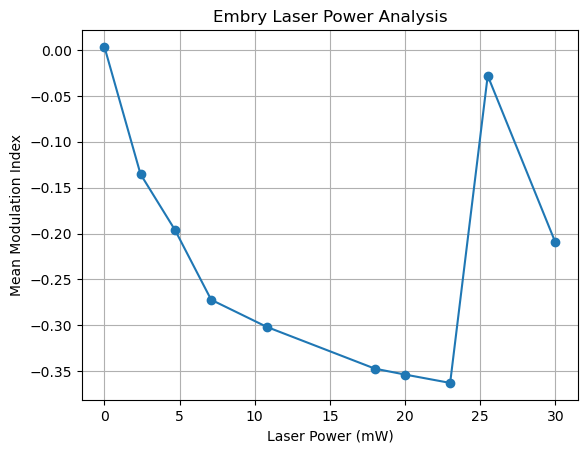

In [ ]:
import matplotlib.pyplot as plt

laser_power = [0, 2.4, 4.7, 7.1, 10.8, 18, 20, 23, 25.5, 30]

plt.plot(laser_power, epoch_mi, marker='o')

plt.xlabel("Laser Power (mW)")
plt.ylabel("Mean Modulation Index")
plt.title("Marcus's Laser Power Analysis")

plt.grid(True)
plt.show()